In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import os

import seaborn as sns


In [3]:
cat_colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, cat_colors_list))    


In [4]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
union_cells_dir = os.path.join(entropy_dir, '_cell_calling_comparison')

# Load peak annotations [including peak AUC score from Genrich peaks]
# Raw peaks are inferred with all reads 
raw_peaks_annot = pd.read_csv(os.path.join(union_cells_dir, 'Rawpeaks/annotation', 'annotated_peaks.bed'),      sep='\t')
raw_peaks_annot['peak_size'] = raw_peaks_annot['End'] - raw_peaks_annot['Start']

# Common peaks are inferred with the common droplets from 3 nuclei-filtering sets (SADE, CR, TSSe)
common_peaks_annot_file = os.path.join(union_cells_dir, 'Commoncells_peaks/annotation', 'annotated_peaks.bed')
common_peaks_annot = pd.read_csv(common_peaks_annot_file, sep='\t')
common_peaks_annot['peak_size'] = common_peaks_annot['End'] - common_peaks_annot['Start']

sade_peaks_annot_file = os.path.join(union_cells_dir, 'Entropy_cells_peaks/annotation/', 'annotated_peaks.bed')
cr_peaks_annot_file = os.path.join(union_cells_dir, 'FRIP_cells_peaks/annotation/', 'annotated_peaks.bed')
tsse_peaks_annot_file = os.path.join(union_cells_dir, 'TSS_cells_peaks/annotation/', 'annotated_peaks.bed')


SADE_vs_raw_annot_sudir = os.path.join(union_cells_dir, 'Entropypeaks_vs_Rawpeaks/annotation')
CR_vs_raw_annot_sudir = os.path.join(union_cells_dir, 'FRIPpeaks_vs_Rawpeaks/annotation')
TSSe_vs_raw_annot_sudir = os.path.join(union_cells_dir, 'TSSpeaks_vs_Rawpeaks/annotation')
common_vs_raw_annot_sudir = os.path.join(union_cells_dir, 'Commonpeaks_vs_Rawpeaks/annotation')

SADE_vs_raw = {}
CR_vs_raw = {}
TSSe_vs_raw = {}
common_vs_raw = {}

for tf, p, d in zip([sade_peaks_annot_file, cr_peaks_annot_file, tsse_peaks_annot_file, common_peaks_annot_file],
    [SADE_vs_raw_annot_sudir, CR_vs_raw_annot_sudir, TSSe_vs_raw_annot_sudir, common_vs_raw_annot_sudir],
                [SADE_vs_raw, CR_vs_raw, TSSe_vs_raw, common_vs_raw]):
    d['whole_peak_set'] = pd.read_csv(tf, sep='\t')
    d['whole_peak_set']['peak_size'] = d['whole_peak_set']['End'] - d['whole_peak_set']['Start']
    
    d['dropped_peaks'] = pd.read_csv(os.path.join(p, 'annotated_lost_peaks.bed'), sep='\t')
    d['newly_discovered_peaks'] = pd.read_csv(os.path.join(p, 'annotated_newly_discovered_peaks.bed'), sep='\t')
    d['dropped_peaks']['peak_size'] = d['dropped_peaks']['End'] - d['dropped_peaks']['Start']
    d['newly_discovered_peaks']['peak_size'] = d['newly_discovered_peaks']['End'] - d['newly_discovered_peaks']['Start']
    

## Peak AUC score 

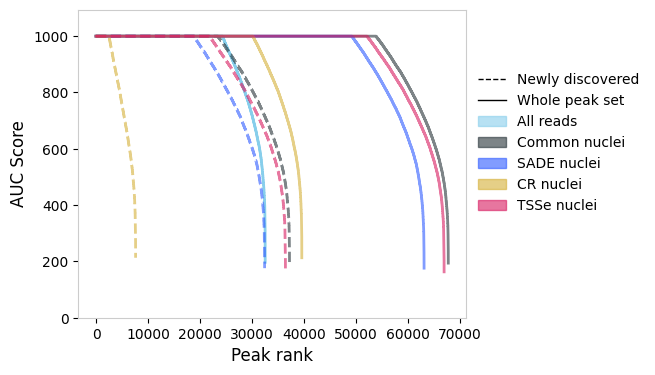

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(raw_peaks_annot['Peak Score'].sort_values(ascending=False).values, '-', color='skyblue', alpha=1, label='Raw peaks', lw=2)

for d, c, l in zip([common_vs_raw, SADE_vs_raw, CR_vs_raw, TSSe_vs_raw], ['#263238','#2E5BFF', "#D4AF37", '#D81B60',],
                    ['Common nuclei', 'SADE nuclei', 'CR nuclei', 'TSSe nuclei']):
    ax.plot(d['whole_peak_set']['Peak Score'].sort_values(ascending=False).values, '-', color=c, alpha=0.6, label=f'{l}', lw=2)
    ax.plot(d['newly_discovered_peaks']['Peak Score'].sort_values(ascending=False).values, '--', color=c, alpha=0.6,  lw=2)


ax.set_xlabel('Peak rank', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0, ax.get_ylim()[1]*1.05)
handles= [ Line2D([0], [0], color='black', lw=1, ls='--', label='Newly discovered'), 
            Line2D([0], [0], color='black', lw=1, ls='-', label='Whole peak set')
          ] + \
            [mpatches.Patch(color='skyblue', alpha=0.6, label='All reads') ] + \
            [ mpatches.Patch(color=c, alpha=0.6, label=l)  for c, l in zip(['#263238', '#2E5BFF', "#D4AF37", '#D81B60',], 
                                                                    ['Common nuclei', 'SADE nuclei', 'CR nuclei', 'TSSe nuclei'])
          ] 
ax.legend(handles=handles, frameon=False, loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=10, ncol=1)

for edge in ['top', 'right', 'left', 'bottom']:
    ax.spines[edge].set_color('#cccccc')

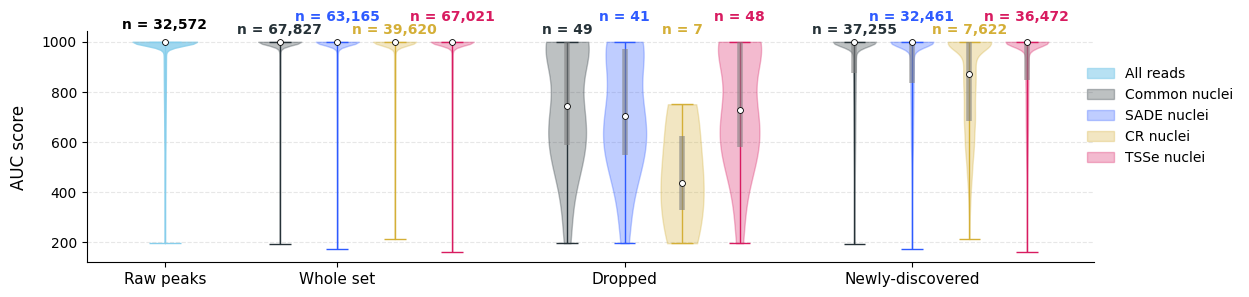

In [ ]:
fig, ax = plt.subplots(figsize=(13, 3))
x_positions = range(4)
width = 0.3 

for d, c, l, poffset, hoffset, c in zip([common_vs_raw, SADE_vs_raw, CR_vs_raw, TSSe_vs_raw], ['#263238','#2E5BFF', "#D4AF37", '#D81B60',],
                    ['Common nuclei', 'SADE nuclei', 'CR nuclei', 'TSSe nuclei'], 
                    0.4*np.array([-1, 0, 1, 2]), 
                    np.array([-0.2, 0.3, -0.2, 0.3]), 
                     ['#263238',  '#2E5BFF', "#D4AF37", '#D81B60',]):
    peaks_score_list = [
        d['whole_peak_set']['Peak Score'],
        d['dropped_peaks']['Peak Score'],
        d['newly_discovered_peaks']['Peak Score'],
    ]

    x_positions_init = [ 2 * i  for i in range(len(peaks_score_list))] 
    x_positions = [pos+ poffset  for pos in x_positions_init]  # Adjust positions for better spacing
    labels = ['Whole set', 'Dropped', 'Newly-discovered']


    v = ax.violinplot( peaks_score_list, positions=x_positions, widths=width, vert=True)

    n_peaks = [len(a) for a in peaks_score_list]
    for i, n in zip(x_positions, n_peaks):
        ax.text(i, ax.get_ylim()[1]*(1.01 + 0.1 * hoffset), f'n = {n:,}', color=c,
                ha='center', fontsize=10, fontweight='bold')

    for t in ['cbars', 'cmaxes', 'cmins']:
        v[t].set_edgecolor(c)
        v[t].set_linewidth(1)
        v[t].set_alpha(1)

    for i, body in enumerate(v['bodies']):
        body.set_facecolor(c)
        body.set_edgecolor(c)
        body.set_alpha(0.3)
        body.set_zorder(2)
        
        data = peaks_score_list[i]
        q1, median, q3 = np.percentile(data, [25, 50, 75])
        mean_val = np.mean(data)
        ax.vlines(x_positions[i], q1, q3, color='grey', lw=4, alpha=0.6)
        ax.scatter(x_positions[i], median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)

# Add raw peaks as a separate violin plot
raw_peaks_x_position = [-1.2]
v = ax.violinplot(
    [raw_peaks_annot['Peak Score']], 
    positions=raw_peaks_x_position , 
    widths=width * 1.5 , 
    vert=True,
)
ax.text(raw_peaks_x_position[0], ax.get_ylim()[1]*1.01, f'n = {len(raw_peaks_annot["Peak Score"]):,}', ha='center', fontsize=10, fontweight='bold')
for t in ['cbars', 'cmaxes', 'cmins', 'bodies']:
    if t == 'bodies':
        v[t][0].set_facecolor('skyblue')
        v[t][0].set_edgecolor('skyblue')
        v[t][0].set_alpha(0.8)
    else:
        v[t].set_edgecolor('skyblue')
        v[t].set_linewidth(1)
        v[t].set_alpha(1)

data = raw_peaks_annot['Peak Score']
q1, median, q3 = np.percentile(data, [25, 50, 75])
mean_val = np.mean(data)
ax.vlines(raw_peaks_x_position[0], q1, q3, color='grey', lw=4, alpha=0.6)
ax.scatter(raw_peaks_x_position[0], median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xticks(raw_peaks_x_position + x_positions_init)
ax.set_xticklabels(['Raw peaks'] + labels, fontsize=11)
ax.set_ylabel('AUC score', fontsize=12, labelpad=10)

handles = [mpatches.Patch(color='skyblue', alpha=0.6, label='All reads') ] + \
[mpatches.Patch(color=c, alpha=0.3, label=l) for c, l in 
           zip(['#263238', '#2E5BFF', "#D4AF37", '#D81B60', ], ['Common nuclei', 'SADE nuclei', 'CR nuclei', 'TSSe nuclei'])]
ax.legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(.98, 0.9), fontsize=10)


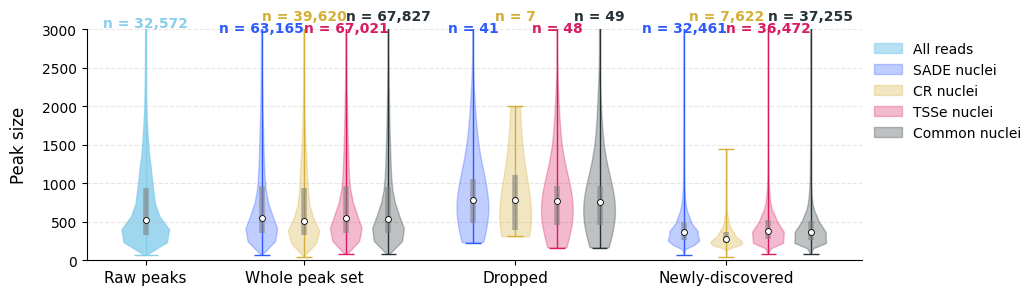

In [46]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_ylim(0, 3000)
x_positions = range(4)
width = 0.3

for d, c, l, poffset, hoffset, c in zip([SADE_vs_raw, CR_vs_raw, TSSe_vs_raw, common_vs_raw], ['#2E5BFF', "#D4AF37", '#D81B60', '#263238'],
                    ['SADE nuclei', 'CR nuclei', 'TSSe nuclei', 'Common nuclei'], 
                    0.4*np.array([-1, 0, 1, 2]), 
                    np.array([-0.2, 0.3, -0.2, 0.3]), 
                     ['#2E5BFF', "#D4AF37", '#D81B60', '#263238']):
    peaks_score_list = [
        d['whole_peak_set']['peak_size'],
        d['dropped_peaks']['peak_size'],
        d['newly_discovered_peaks']['peak_size'],
    ]

    x_positions_init = [ 2 * i  for i in range(len(peaks_score_list))] 
    x_positions = [pos+ poffset  for pos in x_positions_init]  # Adjust positions for better spacing
    labels = ['Whole peak set', 'Dropped', 'Newly-discovered']


    v = ax.violinplot( peaks_score_list, positions=x_positions, widths=width, vert=True)

    n_peaks = [len(a) for a in peaks_score_list]
    for i, n in zip(x_positions, n_peaks):
        ax.text(i, ax.get_ylim()[1]*(1.01 + 0.1 * hoffset), f'n = {n:,}', color=c,
                ha='center', fontsize=10, fontweight='bold')

    for t in ['cbars', 'cmaxes', 'cmins']:
        v[t].set_edgecolor(c)
        v[t].set_linewidth(1)
        v[t].set_alpha(1)
    for i, body in enumerate(v['bodies']):
        body.set_facecolor(c)
        body.set_edgecolor(c)
        body.set_alpha(0.3)
        body.set_zorder(2)
        
        data = peaks_score_list[i]
        q1, median, q3 = np.percentile(data, [25, 50, 75])
        mean_val = np.mean(data)

        ax.vlines(x_positions[i], q1, q3, color='grey', lw=4, alpha=0.6)
        ax.scatter(x_positions[i], median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)

# Add raw peaks as a separate violin plot
raw_peaks_x_position = [-1.5]
v = ax.violinplot(
    [raw_peaks_annot['peak_size']], 
    positions=raw_peaks_x_position , 
    widths=width * 1.5 , 
    vert=True,
)
ax.text(raw_peaks_x_position[0], ax.get_ylim()[1]*1.01, f'n = {len(raw_peaks_annot["peak_size"]):,}', ha='center', fontsize=10, fontweight='bold', color='skyblue')
for t in ['cbars', 'cmaxes', 'cmins', 'bodies']:
    if t == 'bodies':
        v[t][0].set_facecolor('skyblue')
        v[t][0].set_edgecolor('skyblue')
        v[t][0].set_alpha(0.8)
    else:
        v[t].set_edgecolor('skyblue')
        v[t].set_linewidth(1)
        v[t].set_alpha(1)

data = raw_peaks_annot['peak_size']
q1, median, q3 = np.percentile(data, [25, 50, 75])
mean_val = np.mean(data)
ax.vlines(raw_peaks_x_position[0], q1, q3, color='grey', lw=4, alpha=0.6)
ax.scatter(raw_peaks_x_position[0], median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xticks(raw_peaks_x_position + x_positions_init)
ax.set_xticklabels(['Raw peaks'] + labels, fontsize=11)
ax.set_ylabel('Peak size', fontsize=12, labelpad=10)

handles = [mpatches.Patch(color='skyblue', alpha=0.6, label='All reads') ] + \
[mpatches.Patch(color=c, alpha=0.3, label=l) for c, l in zip(['#2E5BFF', "#D4AF37", '#D81B60','#263238'], ['SADE nuclei', 'CR nuclei', 'TSSe nuclei', 'Common nuclei'])]
ax.legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(1., 1), fontsize=10)


# ---

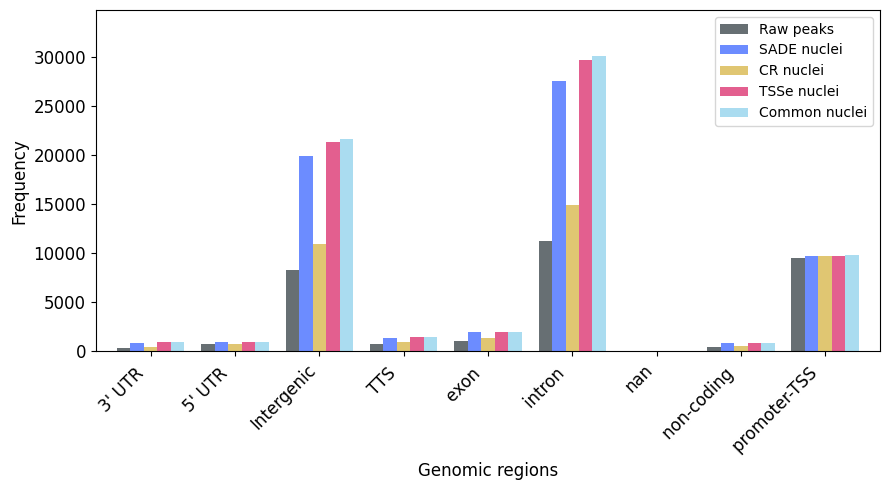

In [51]:
def simplify_annotation(annot_df, inplace=False):
    """
    Simplify the Annotation column.
    """
    if not inplace:
        annot_df = annot_df.copy()
        simple_annotation = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        return simple_annotation
    else:
        # in place change of the  DataFrame
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        
simplify_annotation(raw_peaks_annot, inplace=True)
simplify_annotation(SADE_vs_raw['whole_peak_set'], inplace=True)
simplify_annotation(CR_vs_raw['whole_peak_set'], inplace=True)
simplify_annotation(TSSe_vs_raw['whole_peak_set'], inplace=True)
simplify_annotation(common_vs_raw['whole_peak_set'], inplace=True)

        
raw_peak_freq = raw_peaks_annot['simple_annotation'].value_counts()
sade_peak_freq = SADE_vs_raw['whole_peak_set']['simple_annotation'].value_counts()
cr_peak_freq = CR_vs_raw['whole_peak_set']['simple_annotation'].value_counts()
tsse_peak_freq = TSSe_vs_raw['whole_peak_set']['simple_annotation'].value_counts()
common_peak_freq = common_vs_raw['whole_peak_set']['simple_annotation'].value_counts()

freq_df = pd.DataFrame({
    'Raw peaks': raw_peak_freq,
    'SADE nuclei': sade_peak_freq,
    'CR nuclei': cr_peak_freq,
    'TSSe nuclei': tsse_peak_freq,
    'Common nuclei': common_peak_freq
}).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
freq_df.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=[ '#263238','#2E5BFF', "#D4AF37", '#D81B60', 'skyblue'], fontsize=12)

ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_xlabel('Genomic regions', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
fig.tight_layout()

[Text(0, 0, 'intron '),
 Text(1, 0, 'promoter-TSS '),
 Text(2, 0, 'Intergenic'),
 Text(3, 0, 'exon '),
 Text(4, 0, "5' UTR "),
 Text(5, 0, 'TTS '),
 Text(6, 0, 'non-coding '),
 Text(7, 0, "3' UTR "),
 Text(8, 0, 'nan')]

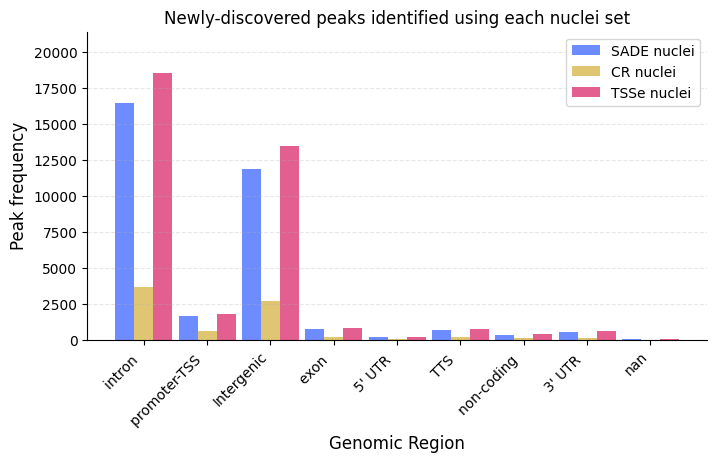

In [ ]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'skyblue', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
index_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

width = 0.3  # the width of the bars
fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(8,4))

for d, c, poffset, l in zip([SADE_vs_raw, CR_vs_raw, TSSe_vs_raw], ['#2E5BFF', "#D4AF37", '#D81B60'],
                    0.3*np.array([-1, 0, 1]),
                    ['SADE nuclei', 'CR nuclei', 'TSSe nuclei']):
    freq_df = simplify_annotation(d['newly_discovered_peaks'], inplace=False).value_counts()
    x_positions = [index_map[idx] + poffset for idx in freq_df.index]
    ax.bar(x_positions, freq_df.values, width=0.3, alpha=0.7, color=c, label=f'{l}')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_ylabel('Peak frequency', fontsize=12)
ax.set_xlabel('Genomic Region', fontsize=12) 
ax.legend(loc='upper right', ncols=1, bbox_to_anchor=(1, 1))
ax.set_title('Newly-discovered peaks identified using each nuclei set')


ticks = sorted(index_map.values())
labels = sorted(index_map, key=index_map.get)
ax.set_xticks(ticks)
ax.set_xticklabels(labels, rotation=45, ha='right')


# plt.show()

In [ ]:
annotation_color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'skyblue', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}